In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("heart.csv")

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
import seaborn as sb

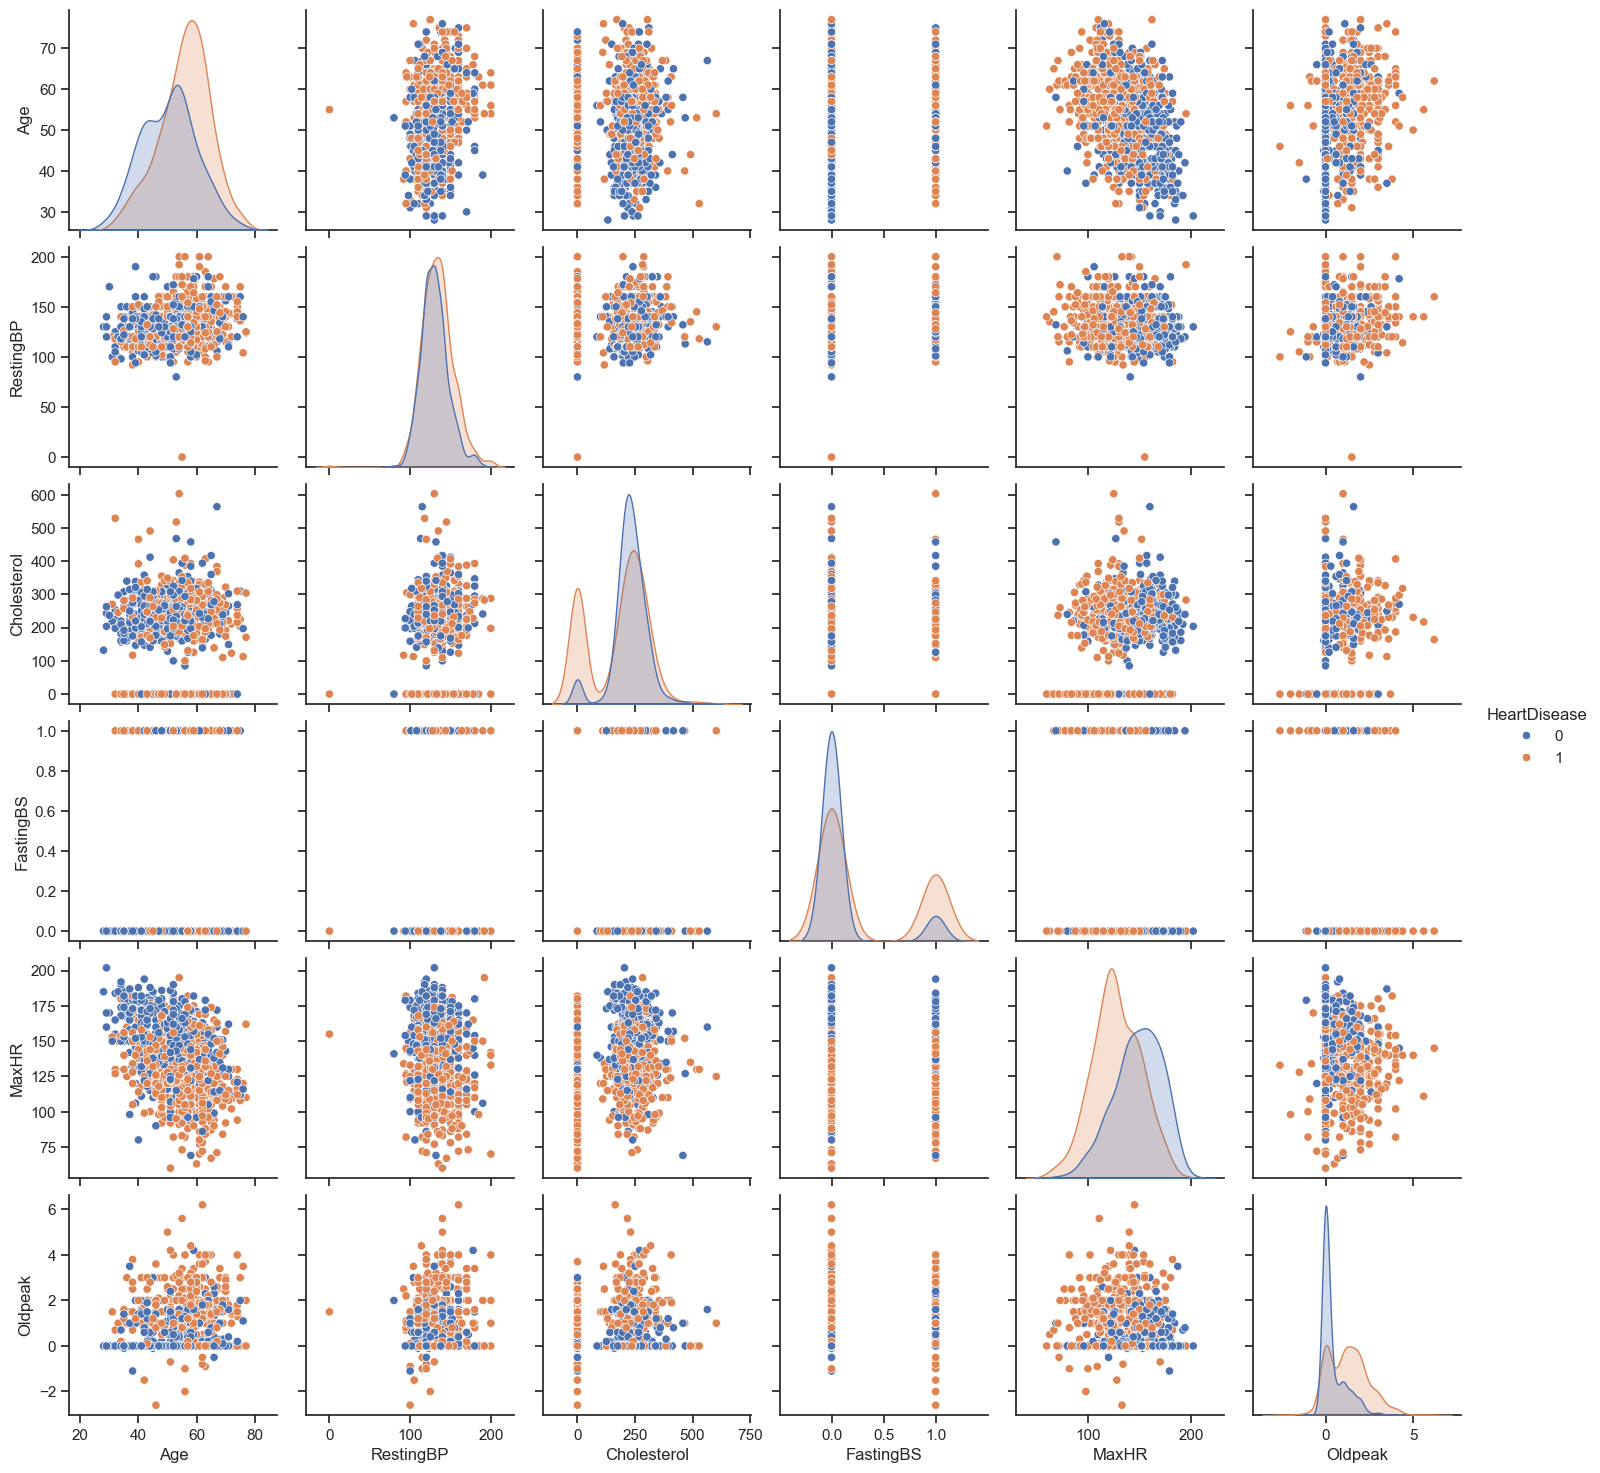

In [7]:
sb.set_theme(style="ticks")
sb.pairplot(data, hue="HeartDisease")

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
train_data, test_data = train_test_split(data,test_size=0.2,random_state=42,stratify=data["HeartDisease"])

In [10]:
train_data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
485,63,M,ATA,139,217,1,ST,128,Y,1.2,Flat,1
486,55,M,ATA,110,214,1,ST,180,N,0.4,Up,0
117,59,F,ASY,130,338,1,ST,130,Y,1.5,Flat,1
361,47,M,ASY,160,0,0,Normal,124,Y,0.0,Flat,1
296,50,M,ASY,145,0,1,Normal,139,Y,0.7,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
276,51,M,NAP,135,160,0,Normal,150,N,2.0,Flat,1
201,46,M,NAP,120,230,0,Normal,150,N,0.0,Up,0
462,59,M,ASY,122,233,0,Normal,117,Y,1.3,Down,1
252,61,M,ASY,125,292,0,ST,115,Y,0.0,Up,0


In [11]:
train_data["HeartDisease"].value_counts()

HeartDisease
1    406
0    328
Name: count, dtype: int64

In [12]:
test_data["HeartDisease"].value_counts()

HeartDisease
1    102
0     82
Name: count, dtype: int64

In [13]:
X_train = train_data.drop("HeartDisease",axis=1)
y_train = train_data["HeartDisease"].copy()
X_test = test_data.drop("HeartDisease",axis=1)
y_test = test_data["HeartDisease"].copy()

In [14]:
len(X_train),len(y_train), len(X_test),len(y_test)

(734, 734, 184, 184)

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [16]:
X_train.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='object')

In [17]:
ordinal_column = ["Sex","RestingECG","ExerciseAngina","ST_Slope"]
onehot_column = ["ChestPainType"]
standard_scaler_column = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]

In [18]:
ordinal = Pipeline([
    ("OrE", OrdinalEncoder())
])

onehot = Pipeline([
    ("OH",OneHotEncoder(handle_unknown="ignore"))
])

stdsc = Pipeline([
    ("StdSc",StandardScaler())
])

preprocessing = ColumnTransformer([
    ("standard scaler",stdsc,standard_scaler_column),
    ("ordinal",ordinal,ordinal_column),
    ("onehot",onehot,onehot_column)
])

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
model_pipeline = Pipeline([
    ("Preprocessing",preprocessing),
    ("Model",RandomForestClassifier(random_state=42))
])

In [21]:
model_pipeline.fit(X_train,y_train)

,steps,"[('Preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('standard scaler', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
from sklearn.model_selection import cross_val_score

In [23]:
cv = cross_val_score(model_pipeline,X_train,y_train,scoring="accuracy",cv=5)

In [24]:
print(cv)
print("Std :",cv.std())
print("Mean :",cv.mean())

[0.89115646 0.85034014 0.86394558 0.82993197 0.82876712]
Std : 0.02324656923830409
Mean : 0.8528282545895071


In [25]:
model_pipeline.score(X_test,y_test)

0.8967391304347826

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as mtp

In [58]:
y_pred = model_pipeline.predict(X_test)
class_label = ["No","Yes"]
print(classification_report(y_test,y_pred,target_names=class_label))

              precision    recall  f1-score   support

          No       0.91      0.85      0.88        82
         Yes       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



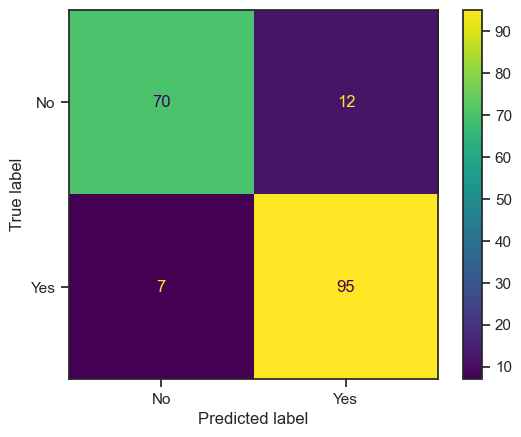

In [73]:
cm = ConfusionMatrixDisplay(confusion_matrix(y_true=y_test,y_pred=y_pred),display_labels=class_label)
cm.plot()
mtp.show()

In [26]:
RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [27]:
from sklearn.model_selection import RandomizedSearchCV

In [97]:
new_pipeline = Pipeline([
    ("Preprocessing",preprocessing),
    ("RandomForest",RandomForestClassifier(random_state=42))
])

parameters_grid = [
    {
        "RandomForest__n_estimators": [100,150, 200, 250, 300],
        "RandomForest__max_depth": [None,15, 20, 25],
        "RandomForest__min_samples_split": [3, 5, 7],
        "RandomForest__min_samples_leaf": [2, 3, 4],
        "RandomForest__max_features": ["sqrt", "log2"],
    }
]

rsc = RandomizedSearchCV(new_pipeline,parameters_grid,scoring="accuracy",random_state=42,cv=3,n_iter=100,n_jobs=-1)
rsc.fit(X_train,y_train)

,estimator,Pipeline(step...m_state=42))])
,param_distributions,"[{'RandomForest__max_depth': [None, 15, ...], 'RandomForest__max_features': ['sqrt', 'log2'], 'RandomForest__min_samples_leaf': [2, 3, ...], 'RandomForest__min_samples_split': [3, 5, ...], ...}]"
,n_iter,100
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [101]:
rsc.best_score_

np.float64(0.871902531504405)

In [102]:
rsc.best_params_

{'RandomForest__n_estimators': 100,
 'RandomForest__min_samples_split': 5,
 'RandomForest__min_samples_leaf': 2,
 'RandomForest__max_features': 'log2',
 'RandomForest__max_depth': 15}

In [103]:
rsc.score(X_test,y_test)

0.9021739130434783

In [76]:
y_pred_new = rsc.predict(X_test)
print(classification_report(y_test,y_pred_new,target_names=class_label))

              precision    recall  f1-score   support

          No       0.91      0.87      0.89        82
         Yes       0.90      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.90      0.90       184
weighted avg       0.90      0.90      0.90       184



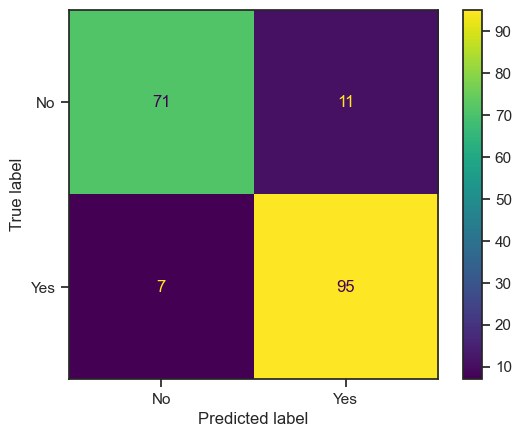

In [78]:
cm2 = ConfusionMatrixDisplay(confusion_matrix(y_true=y_test,y_pred=y_pred_new),display_labels=class_label)
cm2.plot()
mtp.show()

In [105]:
import joblib

In [106]:
joblib.dump(rsc,"model.pkl")

['model.pkl']